# **Sistemas de recomendación**

El objetivo de este Notebook es mostrar la manera de utilizar el algoritmo a priori para crear un sistema de recomendación en el caso de estudios de cosméticos presentado en la clase de Métodos y Aplicaciones de Analítica I

# ***Business understanding*** 

Utilizaremos para este ejemplo el contexto del archivo cosmeticspan.xlsx.

Se trata de una pequeña cadena de cosméticos con productos naturales/orgánicos que se ubica en paneles de 3x3 en grandes tiendas de departamentos y centros comerciales.

El análisis estratégico indicó que era importante buscar:

a) Productos bien vendidos juntos que pudiesen apalancar cross&up-selling por su ubicación en mostrador

b) Productos bien vendidos juntos candidatos a generar un producto innovador dadas las características del mercado

c) Productos premium asociados al labial que pudieran permitir una estrategia de precios

d) Llamar la atención sobre productos de baja venta mediante promociones con otros productos

e) Combinaciones de productos para los canales de redes sociales


#***Data preparation & understanding***



In [ ]:
library(readxl)
cosmetics3 <- read_excel("cosmeticspan.xlsx")

In [ ]:
install.packages("arules")
install.packages("arulesViz")
install.packages("gmodels")
install.packages("vcd")
install.packages("igraph")
install.packages("factoextra")
install.packages("dendextend")
install.packages("grDevices")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘grDevices’ is a base package, and should not be updated”


In [ ]:
library(cluster)
library(factoextra)
library(dendextend)
library(dplyr)
library(grDevices)

Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


---------------------
Welcome to dendextend version 1.16.0
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:stats’:

    cutree



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal

Como vemos, la tabla ya viene preparada como un conjunto de ceros y unos que indican la compra o no compra del producto por el cliente, y contiene 1.000 transacciones de clientes.

Para preparar los datos, dadas las posibles dificultades con datos dispersos, es necesario convertir la base de datos a una clase especial de R.

Cargaremos aquí entonces las librerías y haremos las conversiones, inicialmente a matriz y posteriormene al tipo de datos “transactions”

In [ ]:
#librerías necesarias
library(arules)
library(arulesViz)
#conversión a matriz
cosmetics4<-as.matrix(cosmetics3)
# convertir en transaction
cosmetics4<-as(cosmetics4,"transactions")

Loading required package: Matrix


Attaching package: ‘arules’


The following object is masked from ‘package:dplyr’:

    recode


The following objects are masked from ‘package:base’:

    abbreviate, write




Como mirada descriptiva miremos el tamaño en ventas relativo de los diferentes productos:

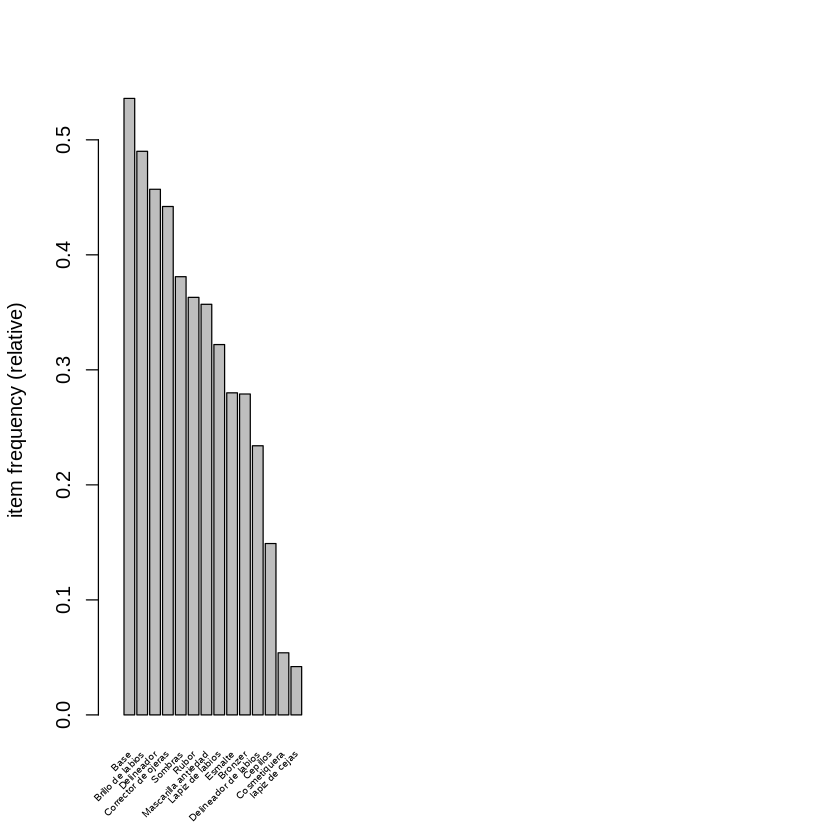

In [ ]:
itemFrequencyPlot(cosmetics4, topN=50,  cex.names=.5)

Esto nos permite ver que los dos productos menos vendidos son el lápiz de cejas y la cosmetiquera (para la estrategia D), mientras que los más populares son el lápiz y el brillo de labios.

# ***Modeling***

##Entendiendo support y lift del algoritmo apriori

Para entender mejor en qué consisten las asociaciones a priori, primero haremos una tabla de contingencia y un gráfico de mosaico

In [ ]:
#obtener una tabla de contingencia
library("gmodels")
crosst<-CrossTable(cosmetics3$Cosmetiquera, cosmetics3$Rubor, chisq = TRUE)


 
   Cell Contents
|-------------------------|
|                       N |
| Chi-square contribution |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  1000 

 
                        | cosmetics3$Rubor 
cosmetics3$Cosmetiquera |         0 |         1 | Row Total | 
------------------------|-----------|-----------|-----------|
                      0 |       615 |       331 |       946 | 
                        |     0.255 |     0.448 |           | 
                        |     0.650 |     0.350 |     0.946 | 
                        |     0.965 |     0.912 |           | 
                        |     0.615 |     0.331 |           | 
------------------------|-----------|-----------|-----------|
                      1 |        22 |        32 |        54 | 
                        |     4.469 |     7.842 |           | 
                        |     0.407 |     0.593 |     0.054 | 
       

In [ ]:
crosst

$t
   y
x     0   1
  0 615 331
  1  22  32

$prop.row
   y
x           0         1
  0 0.6501057 0.3498943
  1 0.4074074 0.5925926

$prop.col
   y
x            0          1
  0 0.96546311 0.91184573
  1 0.03453689 0.08815427

$prop.tbl
   y
x       0     1
  0 0.615 0.331
  1 0.022 0.032

$chisq

	Pearson's Chi-squared test

data:  t
X-squared = 13.013, df = 1, p-value = 0.0003094


$chisq.corr

	Pearson's Chi-squared test with Yates' continuity correction

data:  t
X-squared = 11.984, df = 1, p-value = 0.0005365



Loading required package: grid



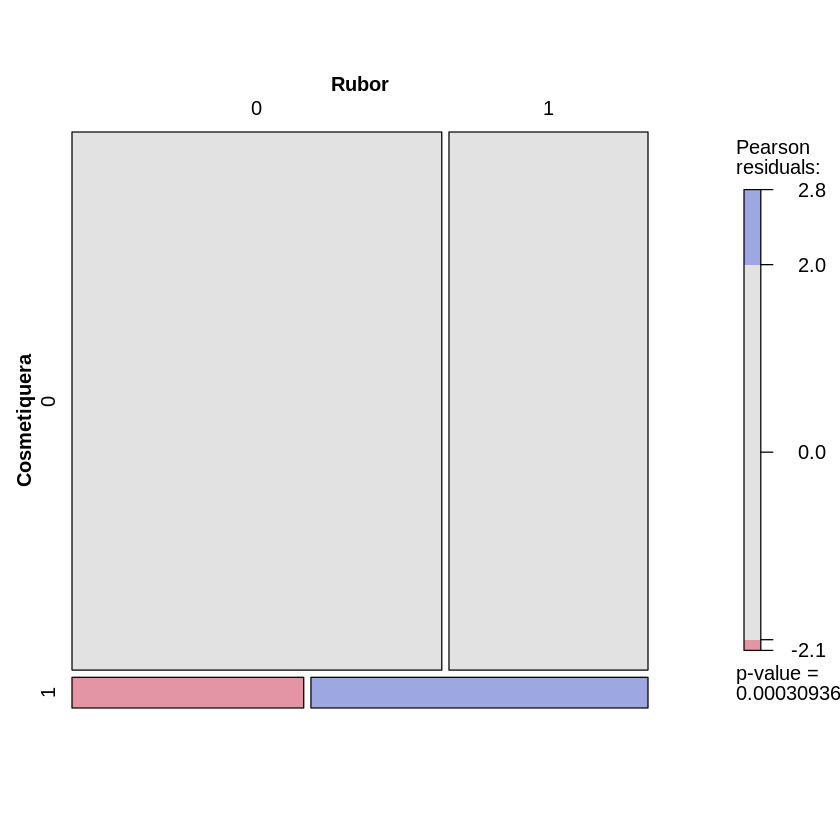

In [ ]:
#graficar el resultado
library("vcd")
mosaic(~Cosmetiquera + Rubor ,data=cosmetics3, 
       legend=TRUE, shade=TRUE)

Como podemos ver, una prueba de hipótesis cuya hipótesis nula es la asociación entre las dos variables obtiene un p-value pequeño, por lo que podemos considerar que hay una asociación en la compra de esos dos productos.

Miremos algunos detalles de lo que aquí se calcula para entender la asociación.

In [ ]:
##valores observados
crosst$chisq.corr$observed

   y
x     0   1
  0 615 331
  1  22  32

In [ ]:
crosst$prop.tbl

   y
x       0     1
  0 0.615 0.331
  1 0.022 0.032

In [ ]:
##valores esperados
crosst$chisq.corr$expected

,0,1
0,602.602,343.398
1,34.398,19.602


Los valores observados (primera tabla) corresponden a lo que realmente ocurrió en las ventas: los productos rubor y cosmetiquera se vendieron 32 veces juntos. Ese valor observado como porcentaje del total corresponde a lo que se denomina support y se puede observar en la segunda tabla que es del 3,2%.

La tercera tabla muestra los valores esperados si los dos productos (o variables fuesen independientes). En este caso se esperaban sólo 19.6 ventas conjuntas, y en realidad ocurrieron 32. EL lift puede obtenerse dividiendo el valor observado sobre el esperado.

In [ ]:
lift<-32/19.6
lift

[1] 1.632653

Este valor implica que los dos productos se vendieron juntos un 63,2% más de lo que se esperaría si fueran independientes en sus ventas.

El lift es una medida de negocio explicativa de lo que ocurre. Pero una medida estadística similar se puede obtener de una tabla chi-cuadrado: los residuales.

In [ ]:
##residuales
crosst$chisq.corr$residuals

   y
x            0          1
  0  0.5050523 -0.6690410
  1 -2.1139029  2.8002799

In [ ]:
##residuales ajustados
crosst$chisq.corr$stdres

   y
x           0         1
  0  3.607332 -3.607332
  1 -3.607332  3.607332

En la primera tabla se obtienen los residuales Chi cuadrado que son una estandarización de los valores observados bajo el supuesto de que la media y la desviación estándar son los valores esperados (suposición Poisson). En ese caso lo que se ve es la posición relativa de los valores esperados en términos de desviaciones estándar (los productos de venden juntos 2.8 desviaciones estándar por encima de lo esperado)

La segunda tabla muestra esos residuales con una modificación importante que debe hacerse en tablas de 2x2. Diríamos entonces que los productos se venden 3.6 desviaciones por encima de lo esperado. Como este último si es un resultado estadístico, lleva como conclusión una prueba de hipótesis que indica que sí hay una asociación entre dichos productos.

Aqui la conversión a matriz:



In [ ]:
cosmetics4<-as.matrix(cosmetics3)

Y aquí la conversión a "transaction"

In [ ]:
cosmetics4<-as(cosmetics4,"transactions")

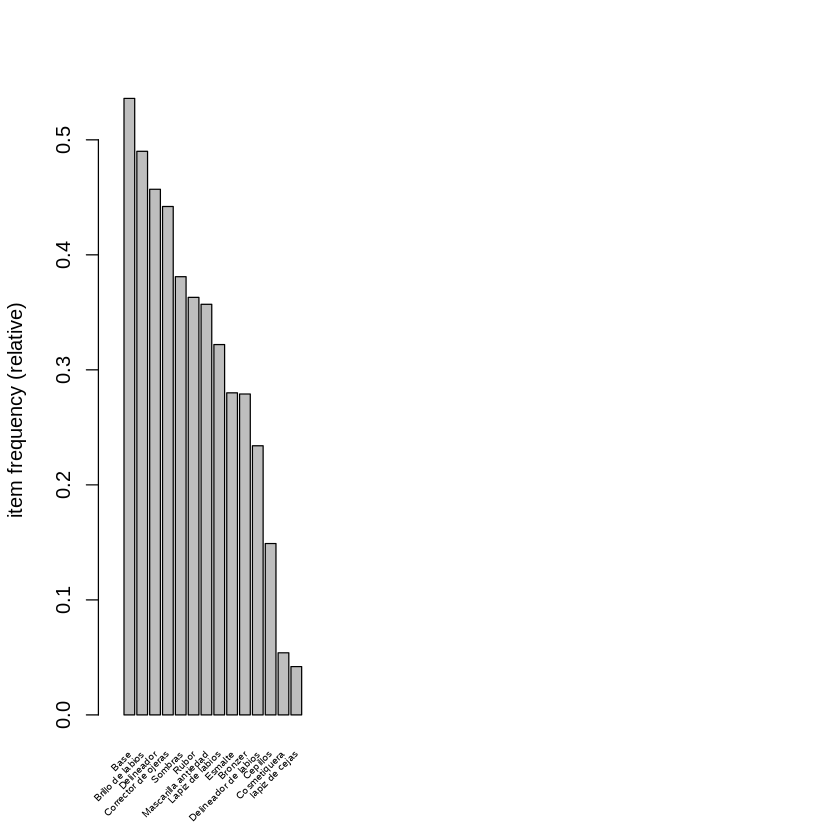

In [ ]:
itemFrequencyPlot(cosmetics4, topN=50,  cex.names=.5)

##Aplicación del algoritmo a priori

Creemos el conjunto de reglas con el algoritmo a priori. Dado el gran volumen de reglas que puede crearse, es clave definir valores de corte de support, confidence o lift que permitan reducir el número de reglas. El support permite seleccionar ventas conjuntas que apliquen a un número mínimo de transacciones. El confidence es muy usado, ante todo, para evitar la duplicación de reglas, porque el support o el lift son iguales para la relación de los productos A y B, sin importar si la relación es (A entonces B) o (B entonces A). Eso hace que muchas reglas salgan repetidas, y el confidence puede ayudar a evitar que esto ocurra.

In [ ]:
rules<-apriori(cosmetics4,parameter=list(support=0.1,confidence=0.6))

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.6    0.1    1 none FALSE            TRUE       5     0.1      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 100 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[14 item(s), 1000 transaction(s)] done [0.00s].
sorting and recoding items ... [12 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 done [0.00s].
writing ... [77 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


Observemos algunas cosas básicas de las reglas: cuantas reglas hay con qué cantidad de productos, y observar las primeras reglas, por ejemplo

In [ ]:
summary(rules)

set of 77 rules

rule length distribution (lhs + rhs):sizes
 2  3  4 
10 55 12 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   3.000   3.000   3.026   3.000   4.000 

summary of quality measures:
    support         confidence        coverage           lift      
 Min.   :0.1020   Min.   :0.6034   Min.   :0.1210   Min.   :1.207  
 1st Qu.:0.1160   1st Qu.:0.6642   1st Qu.:0.1490   1st Qu.:1.419  
 Median :0.1300   Median :0.7254   Median :0.1810   Median :1.684  
 Mean   :0.1476   Mean   :0.7520   Mean   :0.2002   Mean   :1.810  
 3rd Qu.:0.1520   3rd Qu.:0.8538   3rd Qu.:0.2110   3rd Qu.:2.265  
 Max.   :0.3560   Max.   :1.0000   Max.   :0.5360   Max.   :3.571  
     count      
 Min.   :102.0  
 1st Qu.:116.0  
 Median :130.0  
 Mean   :147.6  
 3rd Qu.:152.0  
 Max.   :356.0  

mining info:
       data ntransactions support confidence
 cosmetics4          1000     0.1        0.6
                                                                          call
 apriori(data

In [ ]:
inspect(head(sort(rules,by="lift"),20))

     lhs                       rhs                   support confidence coverage     lift count
[1]  {Cepillos}             => {Esmalte}               0.149  1.0000000    0.149 3.571429   149
[2]  {Rubor,                                                                                   
      Corrector de ojeras,                                                                     
      Sombras}              => {Mascarilla antiedad}   0.119  0.9596774    0.124 2.688172   119
[3]  {Rubor,                                                                                   
      Sombras}              => {Mascarilla antiedad}   0.169  0.9285714    0.182 2.601040   169
[4]  {Esmalte,                                                                                 
      Sombras}              => {Mascarilla antiedad}   0.119  0.9083969    0.131 2.544529   119
[5]  {Corrector de ojeras,                                                                     
      Sombras}              => {Mascaril

Podemos observar, por ejemplo, que el lápiz de labios si está incluido en alguna de las primeras 20 reglas. Así mismo, que hay muchas reglas que involucran 3 productos.


Podemos graficar las reglas por su lift y support

##Gráficos para ver potenciales asociaciones de interés

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



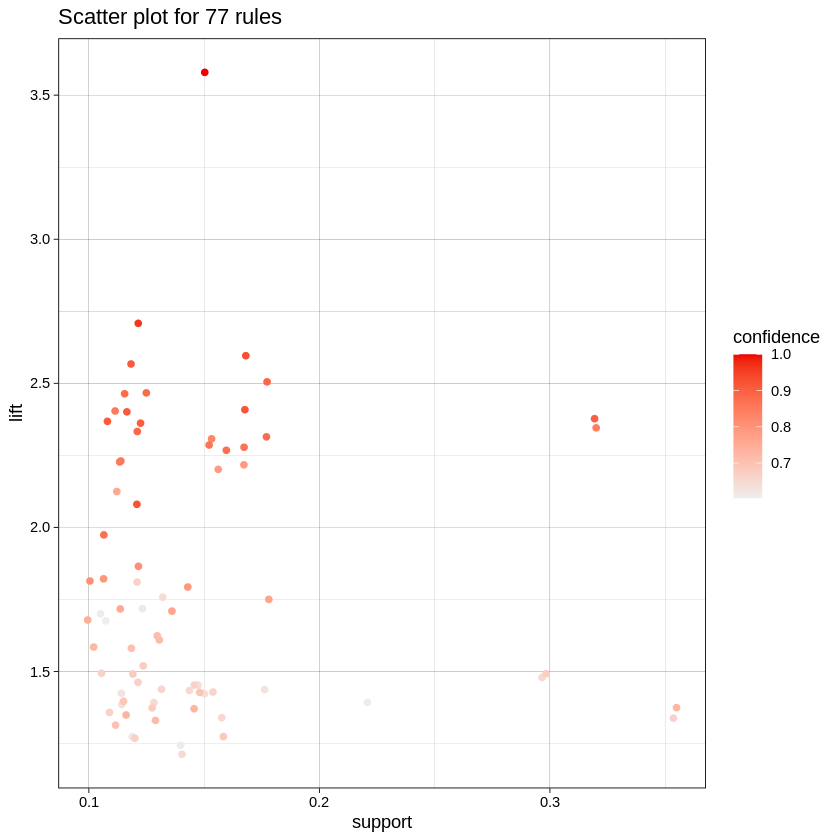

In [ ]:
plot(rules, measure=c("support","lift"), shading="confidence")

Claramente destacan una regla con alto lift (aunque el support no sea muy bueno) y 3 reglas con alto support (más del 30% de las transacciones)

Miremoslas interactivamente

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



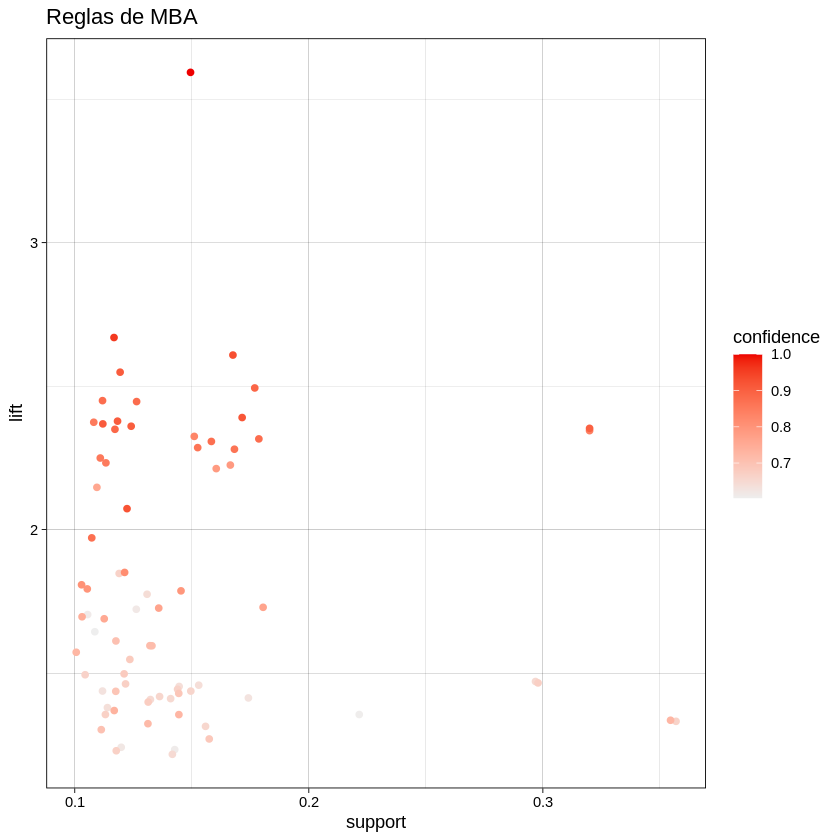

In [ ]:
plot(rules, measure=c("support","lift"), shading="confidence", control=list(main="Reglas de MBA"))

Por ejemplo, si filtramos la zona de alto support con buen lift es visible una regla entre base y brillo de labios. Al tener soporte mayor al 30% y un lift mayor que 2 serán mis candidatas para poner en lugares extremos del mostrador (objetivo A)

Ahora daremos una mirada a las reglas que permita ver qué productos generan la mayor cantidad de reglas. Reduciré a confidence mayor a 0,7.

In [ ]:
inspect(head(sort(rules,by="support"),20))

     lhs                                           rhs                  
[1]  {Brillo de labios}                         => {Base}               
[2]  {Base}                                     => {Brillo de labios}   
[3]  {Mascarilla antiedad}                      => {Sombras}            
[4]  {Sombras}                                  => {Mascarilla antiedad}
[5]  {Delineador}                               => {Corrector de ojeras}
[6]  {Corrector de ojeras}                      => {Delineador}         
[7]  {Rubor}                                    => {Corrector de ojeras}
[8]  {Delineador de labios}                     => {Corrector de ojeras}
[9]  {Corrector de ojeras, Mascarilla antiedad} => {Sombras}            
[10] {Corrector de ojeras, Sombras}             => {Mascarilla antiedad}
[11] {Bronzer}                                  => {Corrector de ojeras}
[12] {Rubor, Mascarilla antiedad}               => {Sombras}            
[13] {Rubor, Sombras}                           => 

Itemsets in Antecedent (LHS)
 [1] "{Cepillos}"                                          
 [2] "{Delineador de labios}"                              
 [3] "{Mascarilla antiedad}"                               
 [4] "{Sombras}"                                           
 [5] "{Brillo de labios}"                                  
 [6] "{Bronzer,Delineador de labios}"                      
 [7] "{Rubor,Delineador de labios}"                        
 [8] "{Delineador de labios,Delineador}"                   
 [9] "{Mascarilla antiedad,Lapiz de labios}"               
[10] "{Sombras,Lapiz de labios}"                           
[11] "{Corrector de ojeras,Lapiz de labios}"               
[12] "{Brillo de labios,Lapiz de labios}"                  
[13] "{Esmalte,Mascarilla antiedad}"                       
[14] "{Esmalte,Sombras}"                                   
[15] "{Rubor,Bronzer}"                                     
[16] "{Bronzer,Mascarilla antiedad}"                       
[17] "{Bron

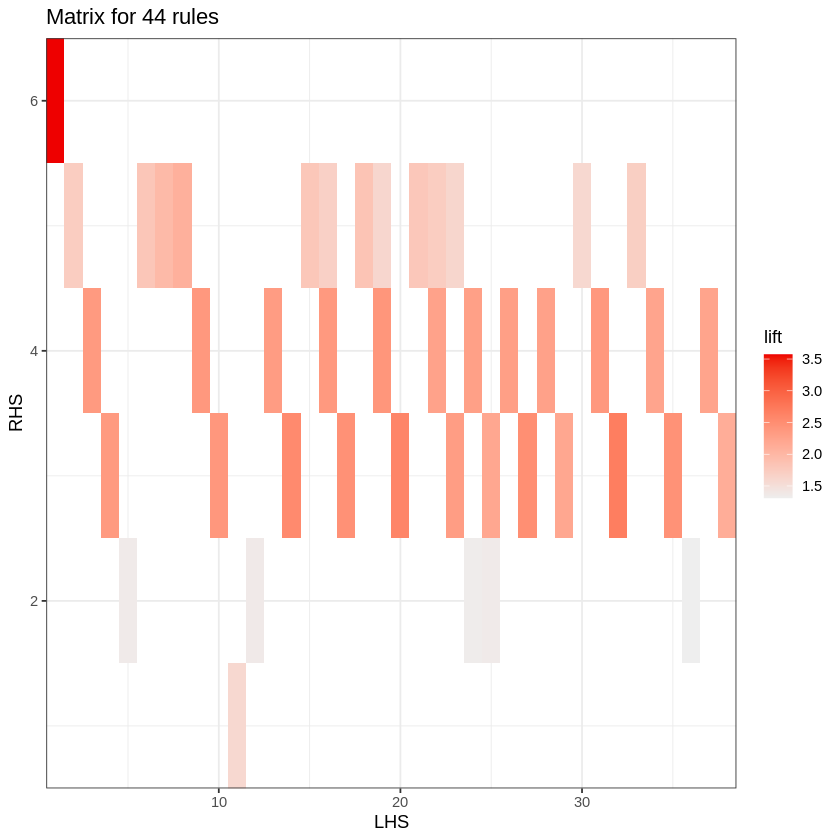

In [ ]:
subrules<-subset(rules,quality(rules)$confidence>0.7)
plot (subrules, method="matrix", measure="lift", control=list(reorder='support/confidence'))

Hay 6 productos que están presentes en todas las reglas, de los cuales 3 se llevan la mayoría. La máscarilla antiedad es una de las que mejor se lleva con otros productos, lo cual coincide con el análisis de industria. El corrector de ojeras o las sombras también tienen gran número de asociaciones.

Una alternativa más compleja pero que permite observar tanto lift como soporte es:

Itemsets in Antecedent (LHS)
 [1] "{Cepillos}"                                          
 [2] "{Delineador de labios}"                              
 [3] "{Mascarilla antiedad}"                               
 [4] "{Sombras}"                                           
 [5] "{Brillo de labios}"                                  
 [6] "{Bronzer,Delineador de labios}"                      
 [7] "{Rubor,Delineador de labios}"                        
 [8] "{Delineador de labios,Delineador}"                   
 [9] "{Mascarilla antiedad,Lapiz de labios}"               
[10] "{Sombras,Lapiz de labios}"                           
[11] "{Corrector de ojeras,Lapiz de labios}"               
[12] "{Brillo de labios,Lapiz de labios}"                  
[13] "{Esmalte,Mascarilla antiedad}"                       
[14] "{Esmalte,Sombras}"                                   
[15] "{Rubor,Bronzer}"                                     
[16] "{Bronzer,Mascarilla antiedad}"                       
[17] "{Bron

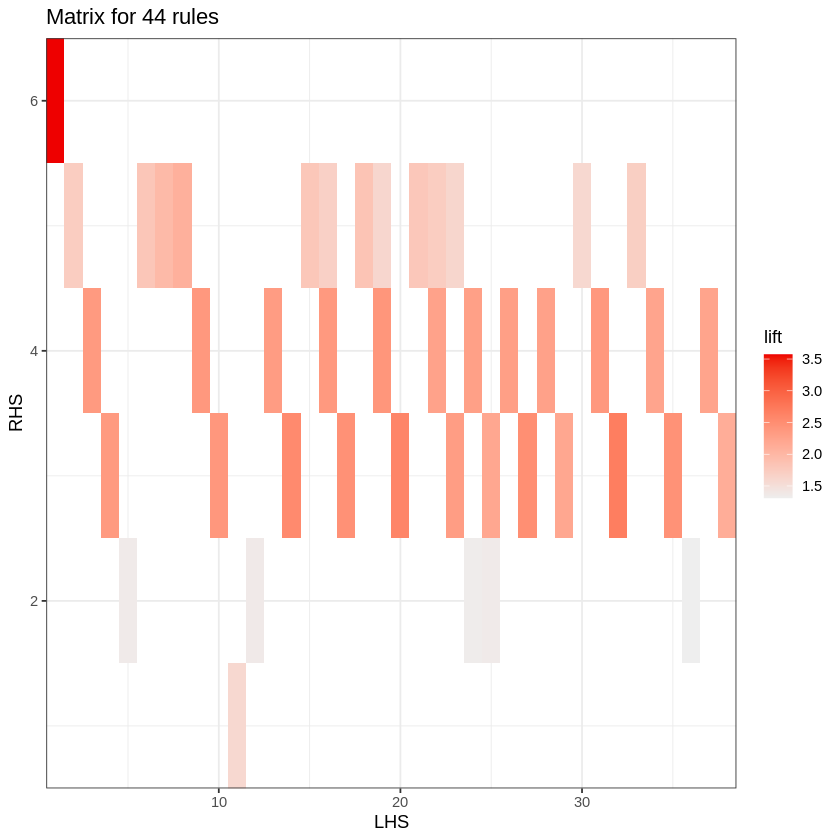

In [ ]:
plot (subrules, method="matrix", measure=c("lift", "support"), control=list(reorder='support/confidence'))

Así mismo, se pueden mirar las asociaciones como si fueran grafos:

In [ ]:
subrules2 <- head(sort(rules, by="lift"), 10)
str(rules)

Formal class 'rules' [package "arules"] with 4 slots
  ..@ lhs    :Formal class 'itemMatrix' [package "arules"] with 3 slots
  .. .. ..@ data       :Formal class 'ngCMatrix' [package "Matrix"] with 5 slots
  .. .. .. .. ..@ i       : int [1:156] 3 7 6 1 8 9 13 4 11 10 ...
  .. .. .. .. ..@ p       : int [1:78] 0 1 2 3 4 5 6 7 8 9 ...
  .. .. .. .. ..@ Dim     : int [1:2] 14 77
  .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. ..$ : NULL
  .. .. .. .. ..@ factors : list()
  .. .. ..@ itemInfo   :'data.frame':	14 obs. of  1 variable:
  .. .. .. ..$ labels: chr [1:14] "Cosmetiquera" "Rubor" "Esmalte" "Cepillos" ...
  .. .. ..@ itemsetInfo:'data.frame':	0 obs. of  0 variables
  ..@ rhs    :Formal class 'itemMatrix' [package "arules"] with 3 slots
  .. .. ..@ data       :Formal class 'ngCMatrix' [package "Matrix"] with 5 slots
  .. .. .. .. ..@ i       : int [1:77] 2 4 4 4 9 8 4 13 10 11 ...
  .. .. .. .. ..@ p       : int [1:78] 0 1 2 3 4 5 6 7 8 9 ...
  .. 

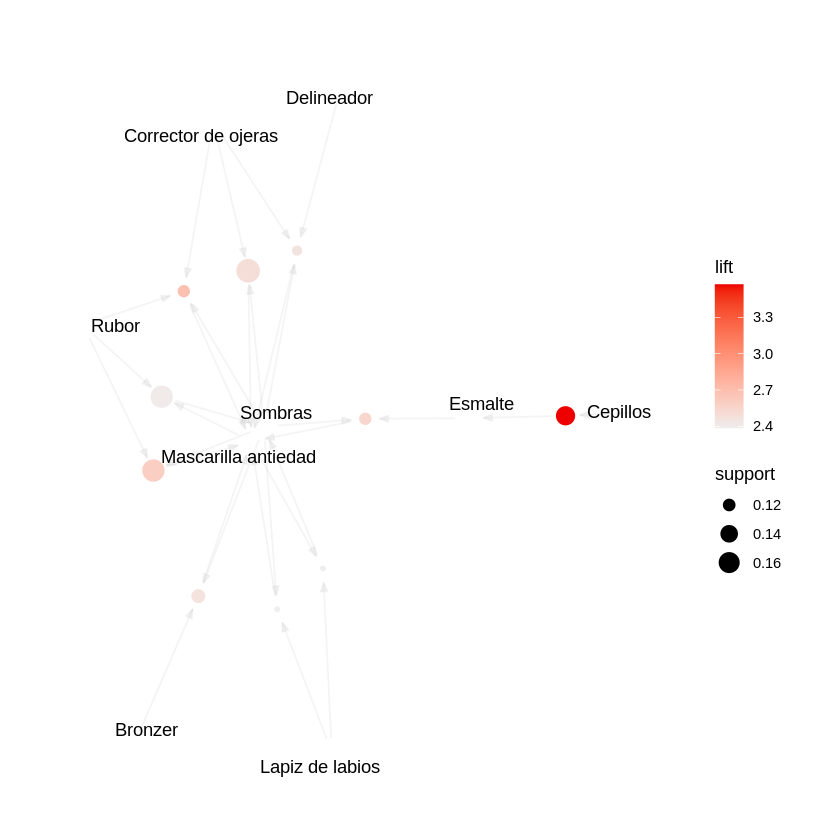

In [ ]:
plot(subrules2, method="graph")

Warning message:
“Unknown control parameters: arrowSize”


Available control parameters (with default values):
layout	 =  stress
circular	 =  FALSE
ggraphdots	 =  NULL
edges	 =  <environment>
nodes	 =  <environment>
nodetext	 =  <environment>
colors	 =  c("#EE0000FF", "#EEEEEEFF")
engine	 =  ggplot2
max	 =  100
verbose	 =  FALSE


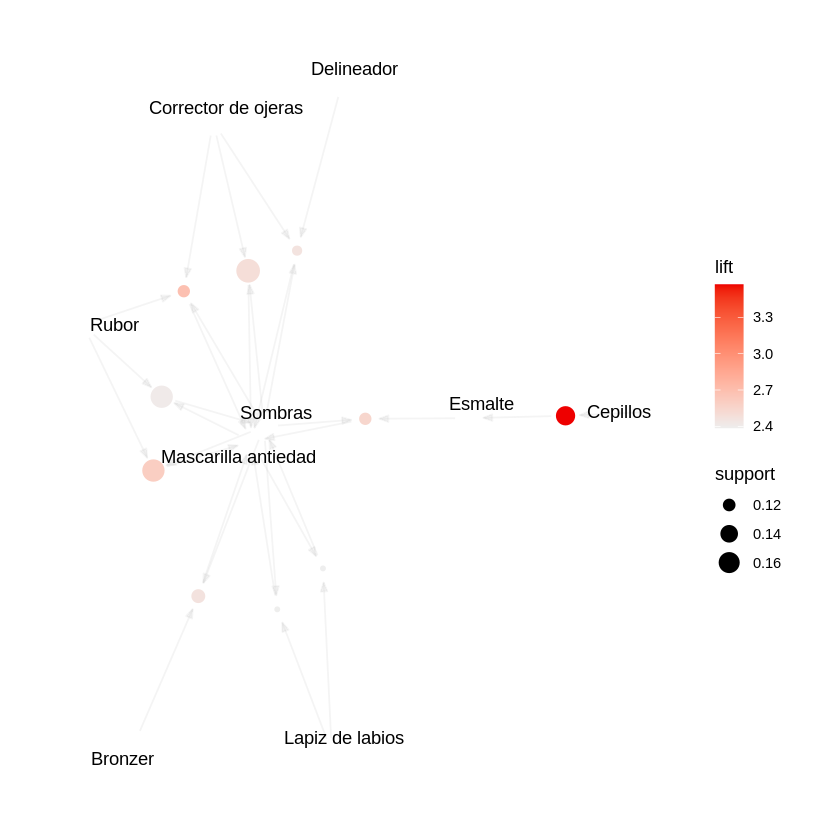

In [ ]:
plot(subrules2, method="graph", arrowSize=.01)

Aquí por ejemplo resalta, además de la máscara y la sombra como elementos centrales en mi portafolio, la relación alta entre cepillos y esmalte.

A partir de la observación de las reglas y de la estrategia de negocios propongo:
a) Base y brillo de labios para la estrategia de ubicación en mostrador, de modo que la gente deba recorrer visualmente el mostrador para encontrar los dos productos. El alto soporte me garantiza muchas miradas
b) La combinación cepillos-esmalte, de altísimo lift y buen soporte para explorar la posibilidad de un producto innovador que pudiese duplicar la funcionalidad
c) Asociado al labial, donde la competencia es fuerte, están la mascarilla antiedad y las sombras. Como la mascarilla antiedad está en crecimiento y es altamente demandada de acuerdo al estudio de industria, se sugiere subir su precio y bajar el del labial para competir mejor, de modo que se mejoren las ganancias
e) Para el canal de redes sociales utilizar en una única promoción productos como el corrector de ojos y el delineador, relacionados con la misma parte de la cara y asociados en ventas
f) Resulta claro que la mascarilla antiedad y las sombras son productos centrales asociados a mi portafolio. Como la mascarilla la estoy usando en la estrategia C como un producto premium, propongo que la sombra se use cuando se requiera la creación de combos o promociones.

Obsérvese que no se planteó la estrategia D, porque ninguna regla se asocia a los productos de baja venta. Eso se debe a que utilizamos el support como criterio de disminución de reglas.

Por ello vamos a crear un nuevo set de reglas con menor soporte que me permita encontrar reglas para los productos de baja venta. Lo reducimos a máximo 3 productos, bajamos el soporte a 1% y las mostramos en orden ascendente:

In [ ]:
rules_lapiz<-subset(rules,subset=lhs %in% "Lapiz de labios")

In [ ]:
inspect(head(sort(rules_lapiz,by="lift"),20))

    lhs                                       rhs                   support
[1] {Sombras, Lapiz de labios}             => {Mascarilla antiedad} 0.110  
[2] {Mascarilla antiedad, Lapiz de labios} => {Sombras}             0.110  
[3] {Corrector de ojeras, Lapiz de labios} => {Delineador}          0.103  
[4] {Lapiz de labios, Delineador}          => {Corrector de ojeras} 0.103  
[5] {Base, Lapiz de labios}                => {Brillo de labios}    0.116  
[6] {Brillo de labios, Lapiz de labios}    => {Base}                0.116  
    confidence coverage lift     count
[1] 0.8527132  0.129    2.388552 110  
[2] 0.9090909  0.121    2.386065 110  
[3] 0.7253521  0.142    1.587204 103  
[4] 0.6645161  0.155    1.503430 103  
[5] 0.6946108  0.167    1.417573 116  
[6] 0.7341772  0.158    1.369734 116  


In [ ]:
rules2<-apriori(cosmetics4,parameter=list(support=0.01,confidence=0.7, maxlen=3))

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.7    0.1    1 none FALSE            TRUE       5    0.01      1
 maxlen target  ext
      3  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 10 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[14 item(s), 1000 transaction(s)] done [0.00s].
sorting and recoding items ... [14 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3

Warning message in apriori(cosmetics4, parameter = list(support = 0.01, confidence = 0.7, :
“Mining stopped (maxlen reached). Only patterns up to a length of 3 returned!”


 done [0.01s].
writing ... [116 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


In [ ]:
inspect(head(sort(rules2,decreasing=FALSE, by="support"),20))

     lhs                       rhs                   support confidence coverage     lift count
[1]  {lapiz de cejas,                                                                          
      Delineador de labios} => {Corrector de ojeras}   0.010  1.0000000    0.010 2.262443    10
[2]  {lapiz de cejas,                                                                          
      Bronzer}              => {Lapiz de labios}       0.010  0.7142857    0.014 2.218279    10
[3]  {lapiz de cejas,                                                                          
      Bronzer}              => {Corrector de ojeras}   0.010  0.7142857    0.014 1.616031    10
[4]  {Cepillos,                                                                                
      lapiz de cejas}       => {Esmalte}               0.011  1.0000000    0.011 3.571429    11
[5]  {lapiz de cejas,                                                                          
      Brillo de labios}     => {Lapiz de

Puedo trabajarlo también como matriz de distancias

In [ ]:
distancias<-dissimilarity(cosmetics4,method="jaccard",which="items")

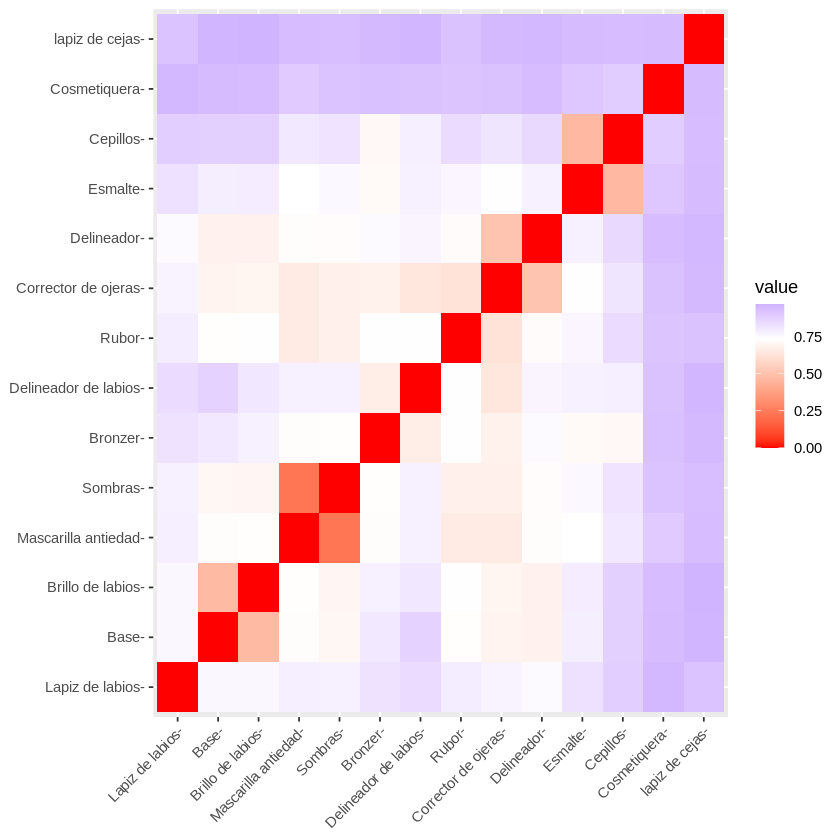

In [ ]:
fviz_dist(dist.obj=distancias)

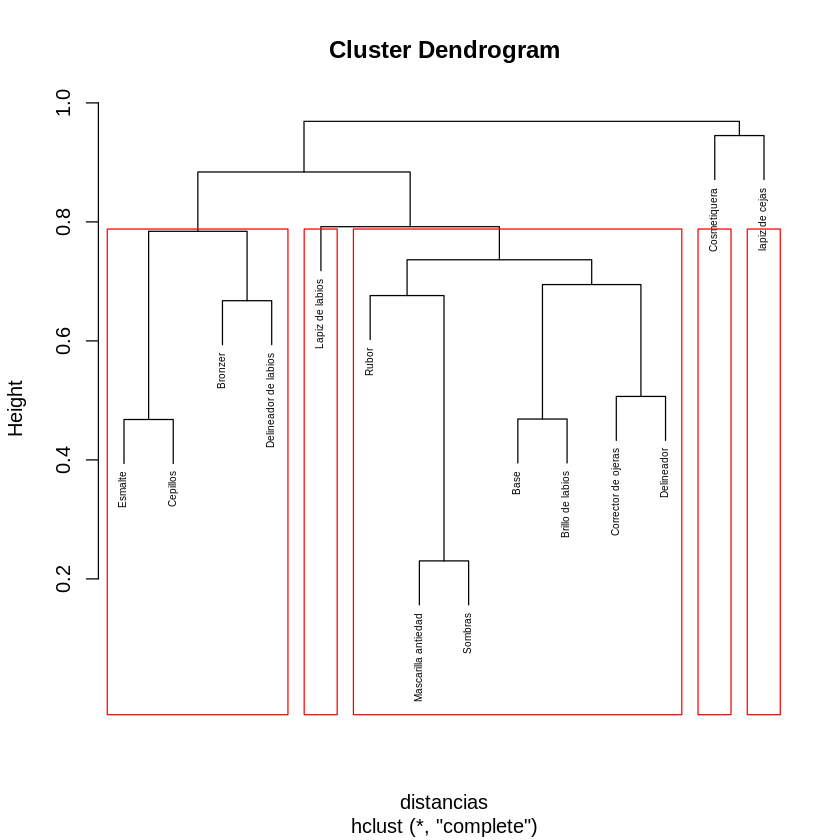

In [ ]:
cosmjer<-hclust(distancias)
plot(cosmjer, cex=0.5)
rect.hclust(cosmjer, k=5,border="red")

  cluster size ave.sil.width
1       1    1          0.00
2       2    7          0.13
3       3    4          0.12
4       4    1          0.00
5       5    1          0.00


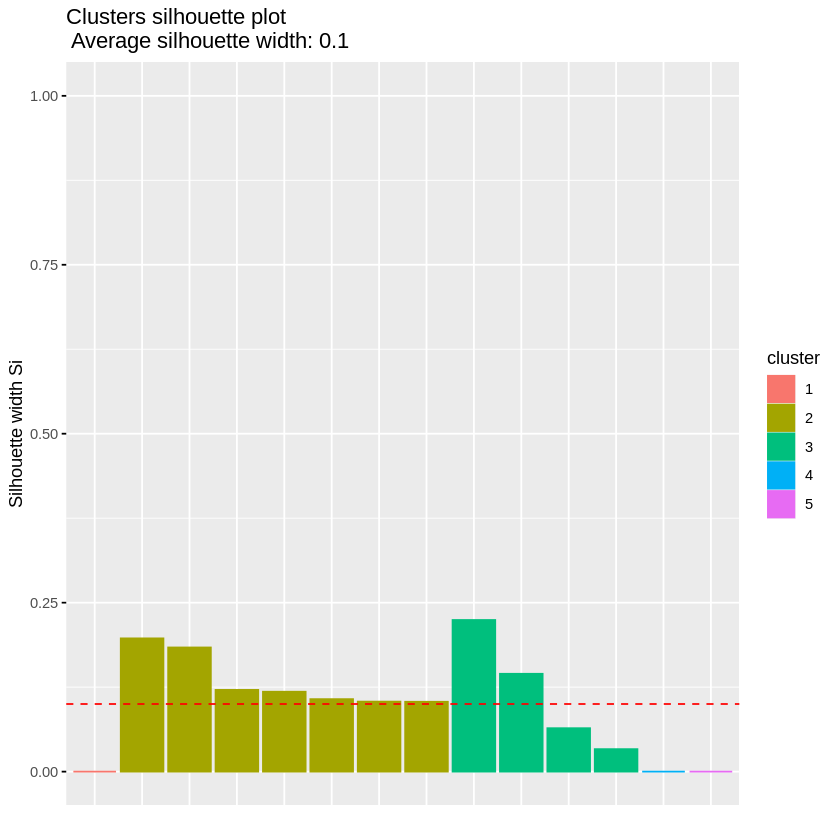

In [ ]:
silueta<-silhouette(cutree(cosmjer,k=5),distancias)
fviz_silhouette(silueta)

Para la estrategia al parecer el esmalte es un buen producto para vender con el lápiz de cejas y/o la cosmetiquera para la estrategia faltante (D).

Finalmente,  llevarme las reglas para análisis:

In [ ]:
write(rules,file="rules.csv",sep=";",dec=",")

##Reglas de asociación como grafos

Vamos a mirar las reglas de asociación como si fuesen grafos. Inicialmente vamos a mirar únicamente las reglas que involucren 2 productos:

In [ ]:
rules2<-apriori(cosmetics4,parameter=list(support=0.001,confidence=0.6, maxlen=2))

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.6    0.1    1 none FALSE            TRUE       5   0.001      1
 maxlen target  ext
      2  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 1 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[14 item(s), 1000 transaction(s)] done [0.00s].
sorting and recoding items ... [14 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2

Warning message in apriori(cosmetics4, parameter = list(support = 0.001, confidence = 0.6, :
“Mining stopped (maxlen reached). Only patterns up to a length of 2 returned!”


 done [0.01s].
writing ... [16 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


In [ ]:
reglas2<-DATAFRAME(rules2)

Creamos variables para graficar después. POr ejemplo, se crea una variable para pintar support en las relaciones (líneas) entre productos(nodos) del grafo

In [ ]:
reglas2$supclass<-as.factor(ifelse(reglas2$support>0.1,"alto","bajo"))

Nodos

In [ ]:
reglas2$nodos1<-as.character(reglas2$LHS)
reglas2$nodos2<-as.character(reglas2$RHS)
reglas2$liftmax<-reglas2$lift*reglas2$lift

In [ ]:
nodostot<-stack(reglas2[,9:10])

In [ ]:
nodos<-as.data.frame(unique(nodostot$values))
nodos$parte<-c("ojos","varios","varios","labios","piel","piel","piel","ojos","ojos","ojos","labios","piel","labios","varios")

Creamos la red 

In [ ]:
library(igraph)
asocred<-graph_from_data_frame(d=reglas2,vertices=nodos,directed=TRUE)


Attaching package: ‘igraph’


The following object is masked from ‘package:arules’:

    union


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




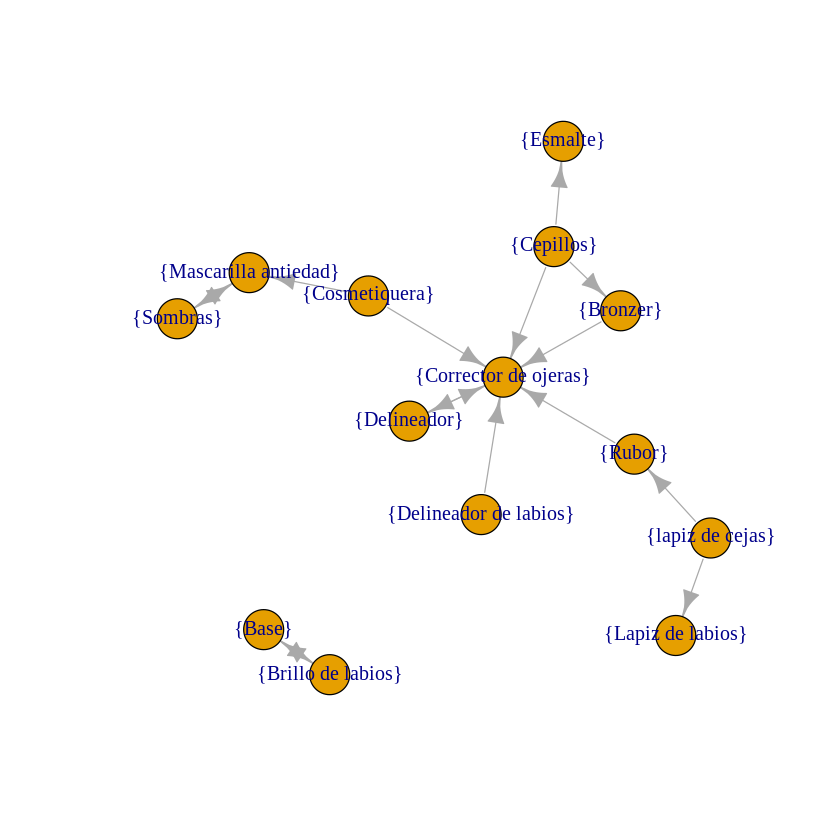

In [ ]:
plot(asocred)

Remuevo si la regla va en ambas direcciones, pero es la misma regla. 

In [ ]:
asocred2 <- simplify(asocred, remove.multiple = T, remove.loops = F)

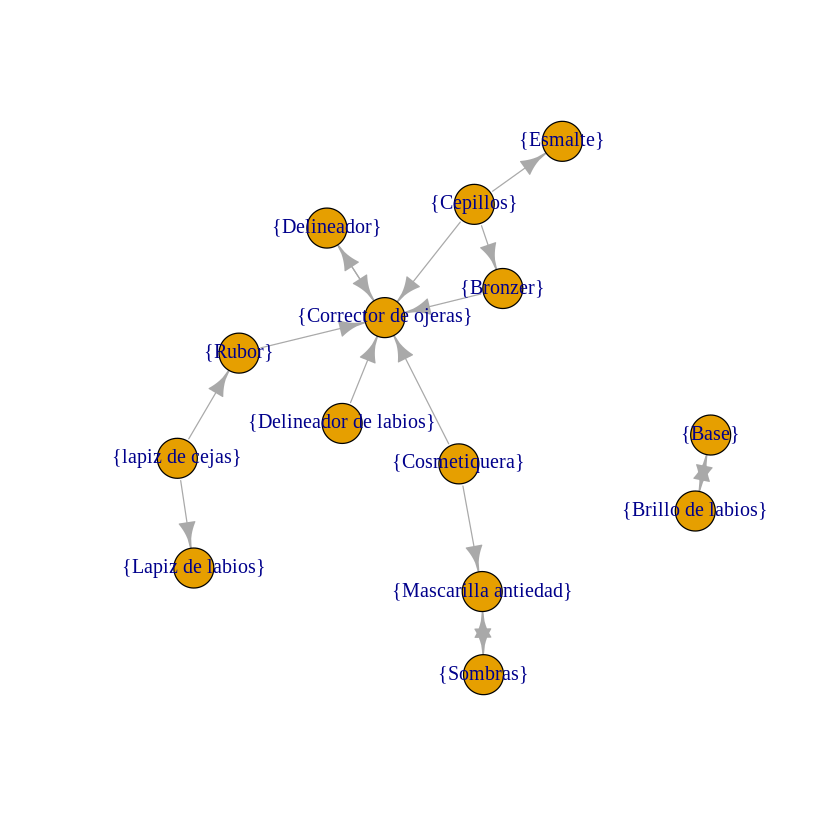

In [ ]:
plot(asocred2)

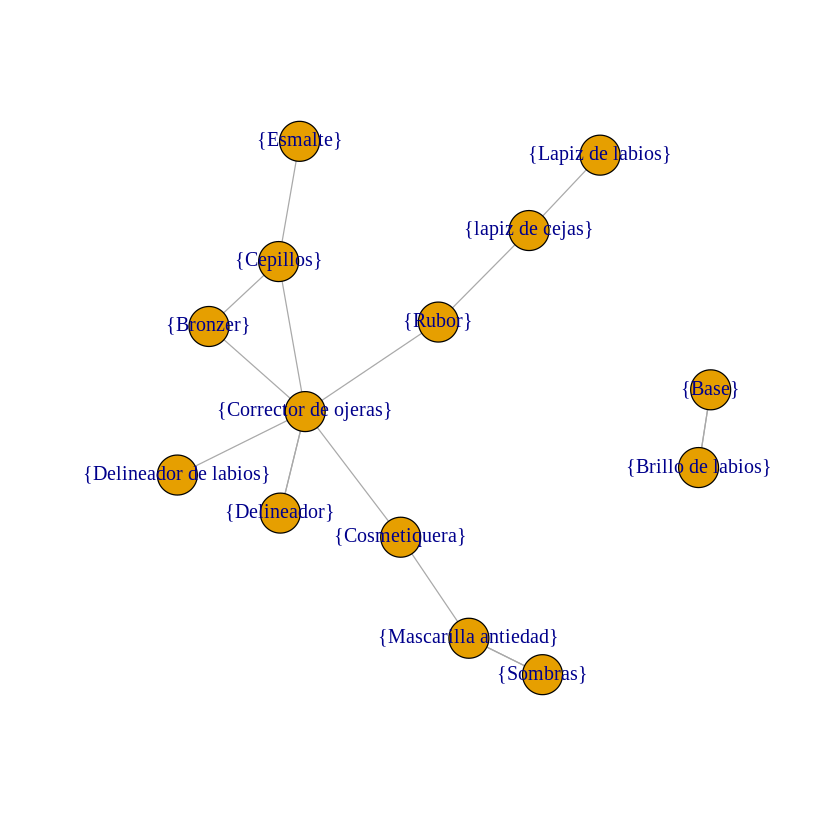

In [ ]:
plot(asocred2,edge.arrow.size=.01)


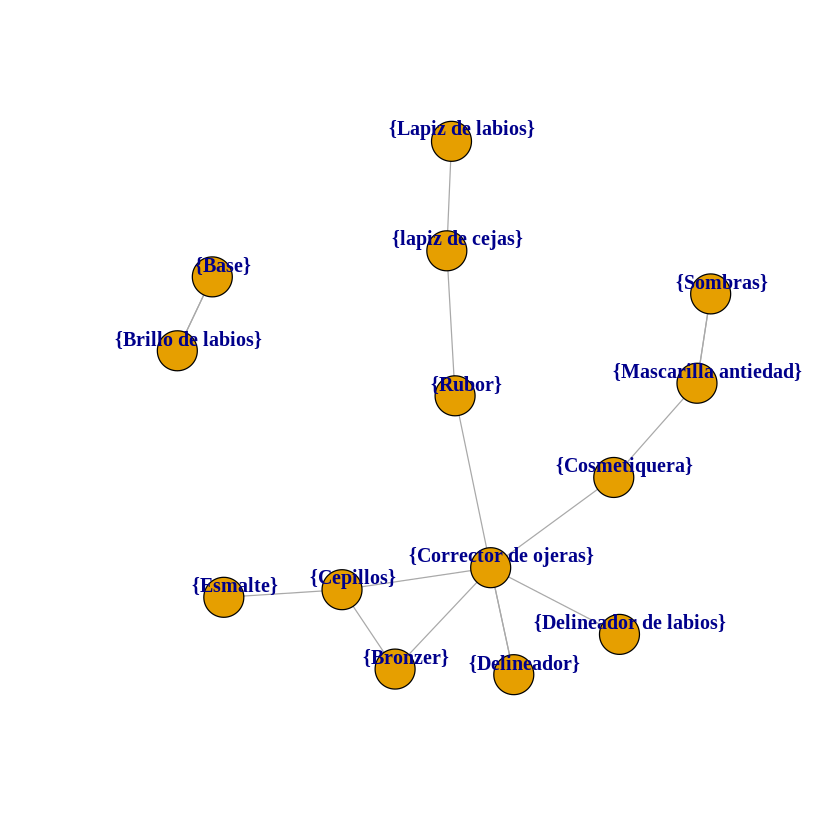

In [ ]:
plot(asocred2,edge.arrow.size=.01, vertex.label.font=2, vertex.label.dist=0.8)

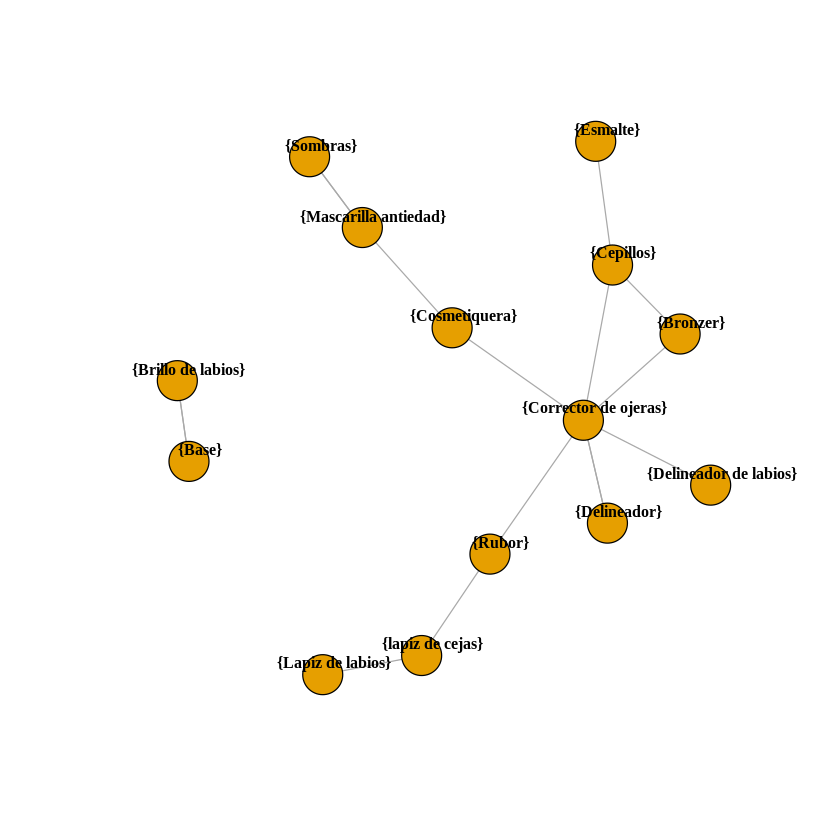

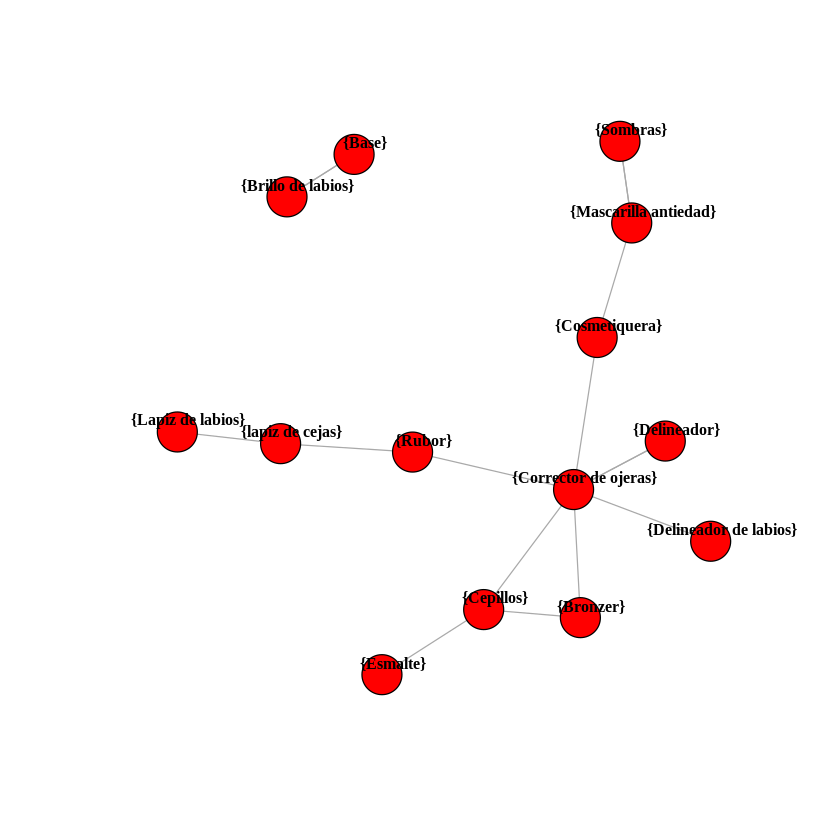

In [ ]:
plot(asocred2,edge.arrow.size=.01, vertex.label.cex=.8, vertex.label.color="black", vertex.label.font=2, vertex.label.dist=0.8)
plot(asocred2,edge.arrow.size=.01, vertex.label.cex=.8, vertex.label.color="black", vertex.label.font=2, vertex.label.dist=0.8, vertex.color="red")

Quiero cambiar un parámetro. P.e, support en el color de la linea

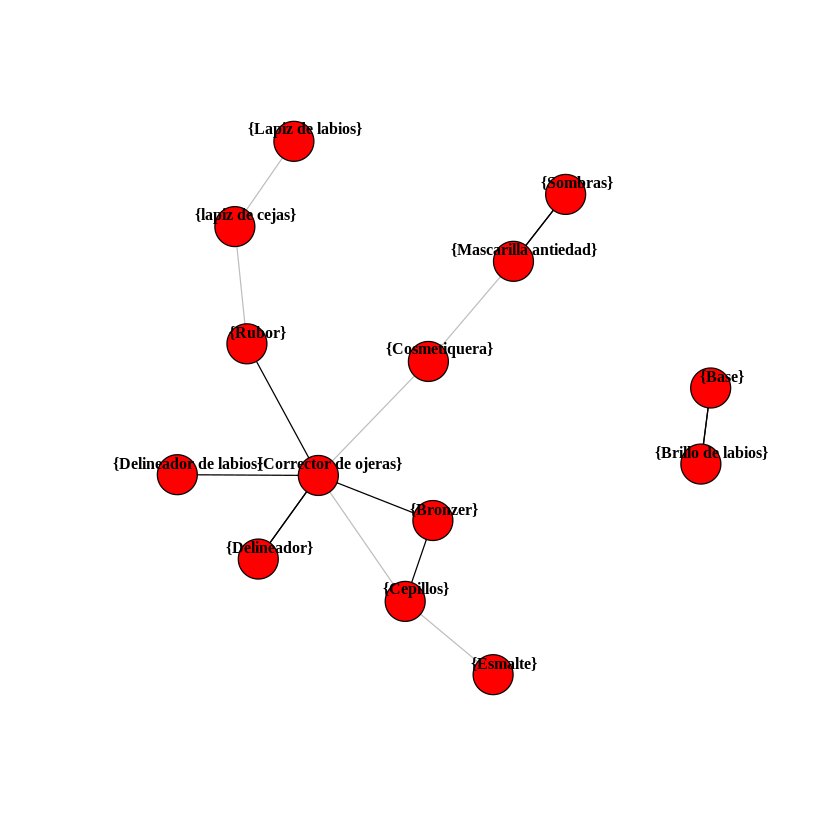

In [ ]:
colorido=c("black","grey")
colorlinea<-colorido[as.numeric(E(asocred2)$supclass)]
plot(asocred2,edge.color=colorido[reglas2$supclass], edge.arrow.size=.01, vertex.label.cex=.8, vertex.label.color="black", vertex.label.font=2, vertex.label.dist=0.8, vertex.color="red")


Ahora ancho de linea por lift

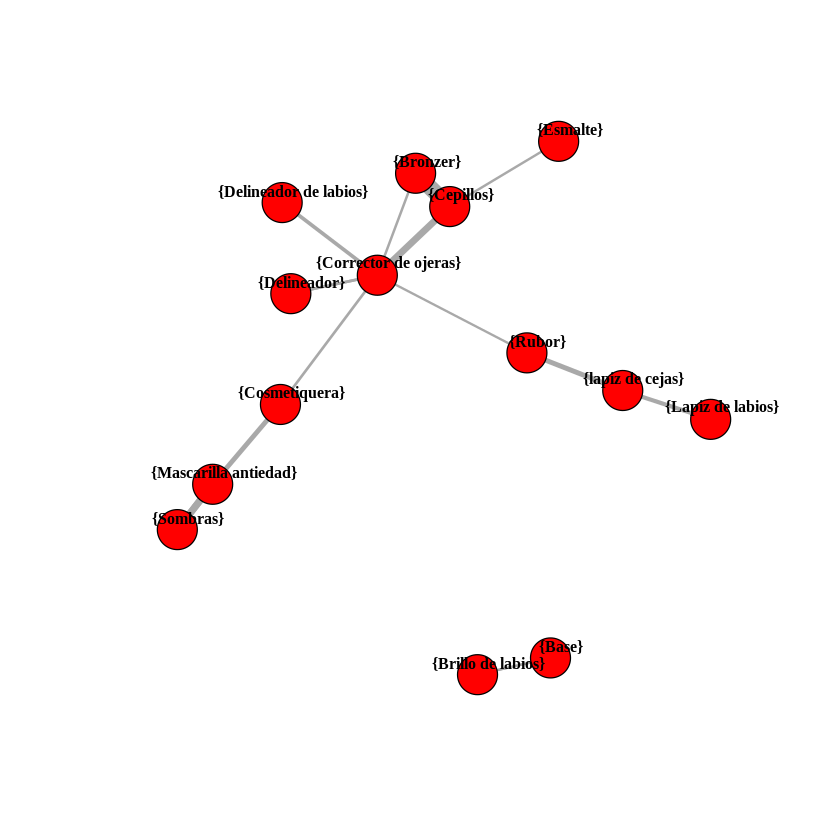

In [ ]:
E(asocred2)$weight<-reglas2$liftmax
plot(asocred2,edge.width=E(asocred2)$weight, edge.arrow.size=.01, vertex.label.cex=.8, vertex.label.color="black", vertex.label.font=2, vertex.label.dist=0.8, vertex.color="red")


Ahora color de acuerdo a tipo de cosmetico

In [ ]:
colorest=c("turquoise3","red3","white","greenyellow")
colorvertice<-colorest[as.numeric(as.factor(V(asocred2)$parte))]

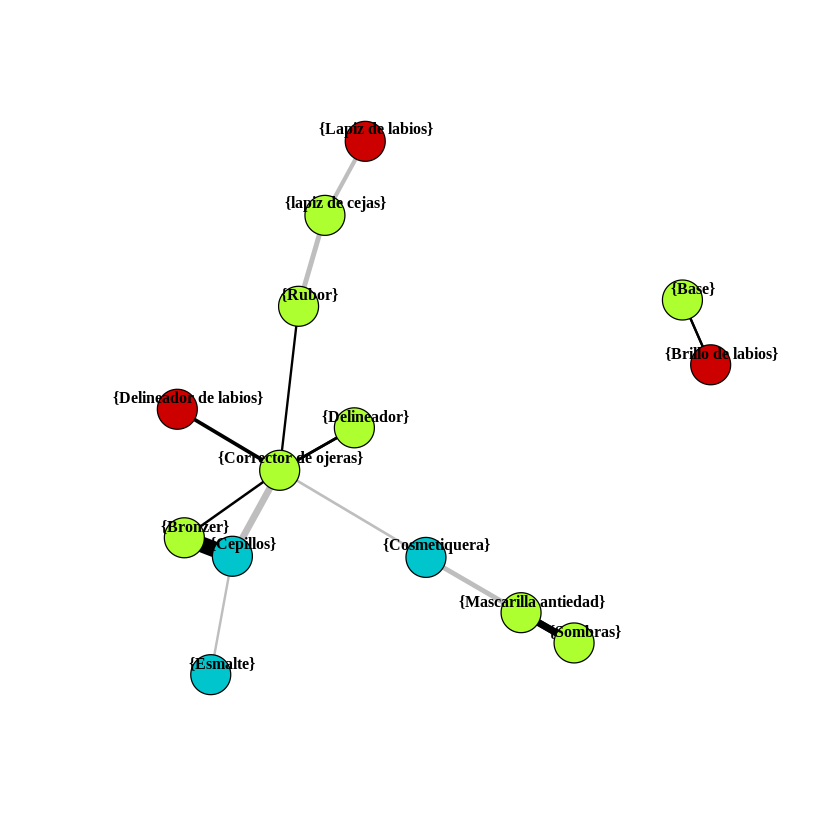

In [ ]:
plot(asocred2,edge.color=colorido[reglas2$supclass],edge.width=E(asocred2)$weight, edge.arrow.size=.01, vertex.label.cex=.8, vertex.label.color="black", vertex.label.font=2, vertex.label.dist=0.8, vertex.color=colorvertice[as.factor(nodos$parte)])


# **Ejercicio Groceries**

A continuación algunos análisis (en borrador) de la base de datos Groceries, la cual se propone como ejercicio para el estudiante, de modo que luego pueda contrastar con algunos de los análisis aquí expuestos.

In [ ]:
data("Groceries")

In [ ]:
summary(Groceries)

transactions as itemMatrix in sparse format with
 9835 rows (elements/itemsets/transactions) and
 169 columns (items) and a density of 0.02609146 

most frequent items:
      whole milk other vegetables       rolls/buns             soda 
            2513             1903             1809             1715 
          yogurt          (Other) 
            1372            34055 

element (itemset/transaction) length distribution:
sizes
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
2159 1643 1299 1005  855  645  545  438  350  246  182  117   78   77   55   46 
  17   18   19   20   21   22   23   24   26   27   28   29   32 
  29   14   14    9   11    4    6    1    1    1    1    3    1 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   3.000   4.409   6.000  32.000 

includes extended item information - examples:
       labels  level2           level1
1 frankfurter sausage meat and sausage
2     sausage sausage meat and sausage
3  live

In [ ]:
str(Groceries)

Formal class 'transactions' [package "arules"] with 3 slots
  ..@ data       :Formal class 'ngCMatrix' [package "Matrix"] with 5 slots
  .. .. ..@ i       : int [1:43367] 13 60 69 78 14 29 98 24 15 29 ...
  .. .. ..@ p       : int [1:9836] 0 4 7 8 12 16 21 22 27 28 ...
  .. .. ..@ Dim     : int [1:2] 169 9835
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : NULL
  .. .. .. ..$ : NULL
  .. .. ..@ factors : list()
  ..@ itemInfo   :'data.frame':	169 obs. of  3 variables:
  .. ..$ labels: chr [1:169] "frankfurter" "sausage" "liver loaf" "ham" ...
  .. ..$ level2: Factor w/ 55 levels "baby food","bags",..: 44 44 44 44 44 44 44 42 42 41 ...
  .. ..$ level1: Factor w/ 10 levels "canned food",..: 6 6 6 6 6 6 6 6 6 6 ...
  ..@ itemsetInfo:'data.frame':	0 obs. of  0 variables


[1] "frankfurter"               "sausage"                  
  [3] "liver loaf"                "ham"                      
  [5] "meat"                      "finished products"        
  [7] "organic sausage"           "chicken"                  
  [9] "turkey"                    "pork"                     
 [11] "beef"                      "hamburger meat"           
 [13] "fish"                      "citrus fruit"             
 [15] "tropical fruit"            "pip fruit"                
 [17] "grapes"                    "berries"                  
 [19] "nuts/prunes"               "root vegetables"          
 [21] "onions"                    "herbs"                    
 [23] "other vegetables"          "packaged fruit/vegetables"
 [25] "whole milk"                "butter"                   
 [27] "curd"                      "dessert"                  
 [29] "butter milk"               "yogurt"                   
 [31] "whipped/sour cream"        "beverages"                
 [33] "UHT-milk"                  "condensed milk"           
 [35] "cream"                     "soft cheese"              
 [37] "sliced cheese"             "hard cheese"              
 [39] "cream cheese "             "processed cheese"         
 [41] "spread cheese"             "curd cheese"              
 [43] "specialty cheese"          "mayonnaise"               
 [45] "salad dressing"            "tidbits"                  
 [47] "frozen vegetables"         "frozen fruits"            
 [49] "frozen meals"              "frozen fish"              
 [51] "frozen chicken"            "ice cream"                
 [53] "frozen dessert"            "frozen potato products"   
 [55] "domestic eggs"             "rolls/buns"               
 [57] "white bread"               "brown bread"              
 [59] "pastry"                    "roll products "           
 [61] "semi-finished bread"       "zwieback"                 
 [63] "potato products"           "flour"                    
 [65] "salt"                      "rice"                     
 [67] "pasta"                     "vinegar"                  
 [69] "oil"                       "margarine"                
 [71] "specialty fat"             "sugar"                    
 [73] "artif. sweetener"          "honey"                    
 [75] "mustard"                   "ketchup"                  
 [77] "spices"                    "soups"                    
 [79] "ready soups"               "Instant food products"    
 [81] "sauces"                    "cereals"                  
 [83] "organic products"          "baking powder"            
 [85] "preservation products"     "pudding powder"           
 [87] "canned vegetables"         "canned fruit"             
 [89] "pickled vegetables"        "specialty vegetables"     
 [91] "jam"                       "sweet spreads"            
 [93] "meat spreads"              "canned fish"              
 [95] "dog food"                  "cat food"                 
 [97] "pet care"                  "baby food"                
 [99] "coffee"                    "instant coffee"           
[101] "tea"                       "cocoa drinks"             
[103] "bottled water"             "soda"                     
[105] "misc. beverages"           "fruit/vegetable juice"    
[107] "syrup"                     "bottled beer"             
[109] "canned beer"               "brandy"                   
[111] "whisky"                    "liquor"                   
[113] "rum"                       "liqueur"                  
[115] "liquor (appetizer)"        "white wine"               
[117] "red/blush wine"            "prosecco"                 
[119] "sparkling wine"            "salty snack"              
[121] "popcorn"                   "nut snack"                
[123] "snack products"            "long life bakery product" 
[125] "waffles"                   "cake bar"                 
[127] "chewing gum"               "chocolate"                
[129] "cooking chocolate"         

[1] meat and sausage     meat and sausage     meat and sausage    
  [4] meat and sausage     meat and sausage     meat and sausage    
  [7] meat and sausage     meat and sausage     meat and sausage    
 [10] meat and sausage     meat and sausage     meat and sausage    
 [13] meat and sausage     fruit and vegetables fruit and vegetables
 [16] fruit and vegetables fruit and vegetables fruit and vegetables
 [19] fruit and vegetables fruit and vegetables fruit and vegetables
 [22] fruit and vegetables fruit and vegetables fruit and vegetables
 [25] fresh products       fresh products       fresh products      
 [28] fresh products       fresh products       fresh products      
 [31] fresh products       fresh products       fresh products      
 [34] fresh products       fresh products       fresh products      
 [37] fresh products       fresh products       fresh products      
 [40] fresh products       fresh products       fresh products      
 [43] fresh products       fresh products       fresh products      
 [46] fresh products       fresh products       fresh products      
 [49] fresh products       fresh products       fresh products      
 [52] fresh products       fresh products       fresh products      
 [55] fresh products       fresh products       fresh products      
 [58] fresh products       fresh products       fresh products      
 [61] fresh products       fresh products       processed food      
 [64] processed food       processed food       processed food      
 [67] processed food       processed food       processed food      
 [70] processed food       processed food       processed food      
 [73] processed food       processed food       processed food      
 [76] processed food       processed food       processed food      
 [79] processed food       processed food       processed food      
 [82] processed food       processed food       processed food      
 [85] processed food       processed food       canned food         
 [88] canned food          canned food          canned food         
 [91] canned food          canned food          canned food         
 [94] canned food          canned food          canned food         
 [97] canned food          canned food          drinks              
[100] drinks               drinks               drinks              
[103] drinks               drinks               drinks              
[106] drinks               drinks               drinks              
[109] drinks               drinks               drinks              
[112] drinks               drinks               drinks              
[115] drinks               drinks               drinks              
[118] drinks               drinks               snacks and candies  
[121] snacks and candies   snacks and candies   snacks and candies  
[124] snacks and candies   snacks and candies   snacks and candies  
[127] snacks and candies   snacks and candies   snacks and candies  
[130] snacks and candies   snacks and candies   snacks and candies  
[133] snacks and candies   snacks and candies   detergent           
[136] detergent            detergent            detergent           
[139] detergent            detergent            detergent           
[142] detergent            perfumery            perfumery           
[145] perfumery            perfumery            perfumery           
[148] perfumery            perfumery            perfumery           
[151] perfumery            perfumery            perfumery           
[154] non-food             non-food             non-food            
[157] non-food             non-food             non-food            
[160] non-food             non-food             non-food            
[163] non-food             non-food             non-food            
[166] non-food             non-food             non-food            
[169] non-food            
10 Levels: canned food detergent drinks fresh products ... snacks and candies

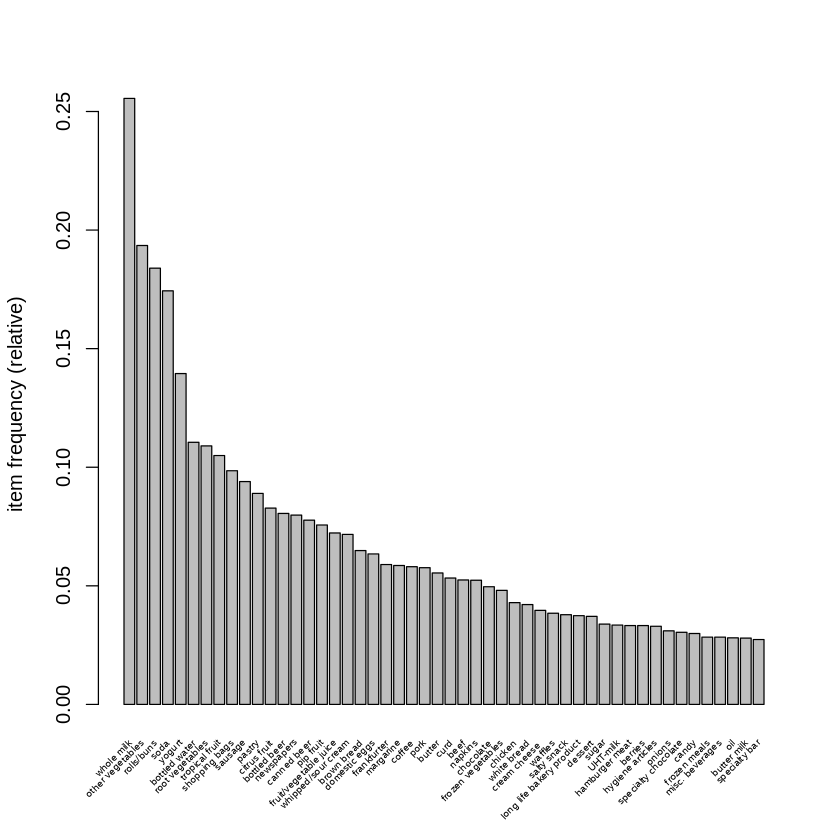

In [ ]:
Groceries@itemInfo$labels
Groceries@itemInfo$level1
itemFrequencyPlot(Groceries, topN=50,  cex.names=.5)

Reglas

In [ ]:
rulesg<-apriori(Groceries,parameter=list(support=0.001,confidence=0.6))
summary(rulesg)

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.6    0.1    1 none FALSE            TRUE       5   0.001      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 9 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.00s].
sorting and recoding items ... [157 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 done [0.02s].
writing ... [2918 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


set of 2918 rules

rule length distribution (lhs + rhs):sizes
   2    3    4    5    6 
   3  490 1765  626   34 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   4.000   4.000   4.068   4.000   6.000 

summary of quality measures:
    support           confidence        coverage             lift       
 Min.   :0.001017   Min.   :0.6000   Min.   :0.001017   Min.   : 2.348  
 1st Qu.:0.001118   1st Qu.:0.6316   1st Qu.:0.001525   1st Qu.: 2.668  
 Median :0.001220   Median :0.6818   Median :0.001830   Median : 3.168  
 Mean   :0.001480   Mean   :0.7028   Mean   :0.002157   Mean   : 3.450  
 3rd Qu.:0.001525   3rd Qu.:0.7500   3rd Qu.:0.002339   3rd Qu.: 3.692  
 Max.   :0.009354   Max.   :1.0000   Max.   :0.014642   Max.   :18.996  
     count      
 Min.   :10.00  
 1st Qu.:11.00  
 Median :12.00  
 Mean   :14.55  
 3rd Qu.:15.00  
 Max.   :92.00  

mining info:
      data ntransactions support confidence
 Groceries          9835   0.001        0.6
                         

Los items se ordenan por support aquí

In [ ]:
cruzadas<-crossTable(Groceries,measure="lift",sort=TRUE)
cruzadas

,whole milk,other vegetables,rolls/buns,soda,yogurt,bottled water,root vegetables,tropical fruit,shopping bags,sausage,⋯,whisky,make up remover,toilet cleaner,frozen chicken,baby cosmetics,kitchen utensil,bags,preservation products,baby food,sound storage medium
whole milk,NA,1.5136341,1.2050318,0.8991124,1.5717351,1.2169396,1.7560310,1.5775950,0.9733637,1.2452520,⋯,0.4892061,0.9784123,1.118185,1.3045497,1.9568245,2.935237,0.9784123,1.956825,0.000000,0.000000
other vegetables,1.5136341,NA,1.1970465,0.9703476,1.6084566,1.1601012,2.2466049,1.7677896,1.2160366,1.4822091,⋯,1.2920389,0.6460194,1.476616,0.0000000,0.8613593,1.292039,0.0000000,2.584078,5.168156,0.000000
rolls/buns,1.2050318,1.1970465,NA,1.1951242,1.3393633,1.1903734,1.2121013,1.2748863,1.0772419,1.7710480,⋯,1.3591763,1.3591763,0.000000,0.9061176,1.8122351,1.359176,1.3591763,0.000000,5.436705,0.000000
soda,0.8991124,0.9703476,1.1951242,NA,1.1243678,1.5035766,0.9789636,1.1391592,1.4321939,1.4833245,⋯,0.0000000,2.8673469,0.819242,0.9557823,1.9115646,1.433673,0.0000000,0.000000,0.000000,5.734694
yogurt,1.5717351,1.6084566,1.3393633,1.1243678,NA,1.4903873,1.6984751,2.0004746,1.1096544,1.4972889,⋯,0.8960459,0.8960459,1.024052,2.3894558,0.0000000,3.584184,1.7920918,3.584184,7.168367,0.000000
bottled water,1.2169396,1.1601012,1.1903734,1.5035766,1.4903873,NA,1.2997827,1.5956459,1.0084278,1.1554598,⋯,2.2619595,1.1309798,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,9.047838
root vegetables,1.7560310,2.2466049,1.2121013,0.9789636,1.6984751,1.2997827,NA,1.8402220,1.1929613,1.4595700,⋯,1.1468050,0.0000000,2.621269,0.0000000,1.5290734,0.000000,2.2936101,0.000000,0.000000,0.000000
tropical fruit,1.5775950,1.7677896,1.2748863,1.1391592,2.0004746,1.5956459,1.8402220,NA,1.3080445,1.4130036,⋯,0.0000000,2.3825097,1.361434,1.5883398,1.5883398,4.765019,0.0000000,4.765019,9.530039,0.000000
shopping bags,0.9733637,1.2160366,1.0772419,1.4321939,1.1096544,1.0084278,1.1929613,1.3080445,NA,1.6916065,⋯,2.5374097,1.2687049,2.899897,1.6916065,1.6916065,0.000000,0.0000000,0.000000,10.149639,10.149639
sausage,1.2452520,1.4822091,1.7710480,1.4833245,1.4972889,1.1554598,1.4595700,1.4130036,1.6916065,NA,⋯,0.0000000,1.3304924,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,10.643939,0.000000


Por un lado los productos a "combinar"

In [ ]:
inspect(head(sort(rulesg,by="lift"),20))

     lhs                         rhs                         support confidence    coverage      lift count
[1]  {Instant food products,                                                                               
      soda}                   => {hamburger meat}        0.001220132  0.6315789 0.001931876 18.995654    12
[2]  {soda,                                                                                                
      popcorn}                => {salty snack}           0.001220132  0.6315789 0.001931876 16.697793    12
[3]  {ham,                                                                                                 
      processed cheese}       => {white bread}           0.001931876  0.6333333 0.003050330 15.045491    19
[4]  {tropical fruit,                                                                                      
      other vegetables,                                                                                    
      yogurt,               

Por el otro lado los productos que van juntos

In [ ]:
inspect(head(sort(rulesg,by="support"),20))

     lhs                     rhs                    support confidence    coverage     lift count
[1]  {butter,                                                                                    
      yogurt}             => {whole milk}       0.009354347  0.6388889 0.014641586 2.500387    92
[2]  {root vegetables,                                                                           
      butter}             => {whole milk}       0.008235892  0.6377953 0.012913066 2.496107    81
[3]  {root vegetables,                                                                           
      other vegetables,                                                                          
      yogurt}             => {whole milk}       0.007829181  0.6062992 0.012913066 2.372842    77
[4]  {tropical fruit,                                                                            
      other vegetables,                                                                          
      yogurt}       

Gráficos para ver "clusteres" de reglas. Buscar productos con alto lift /support

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



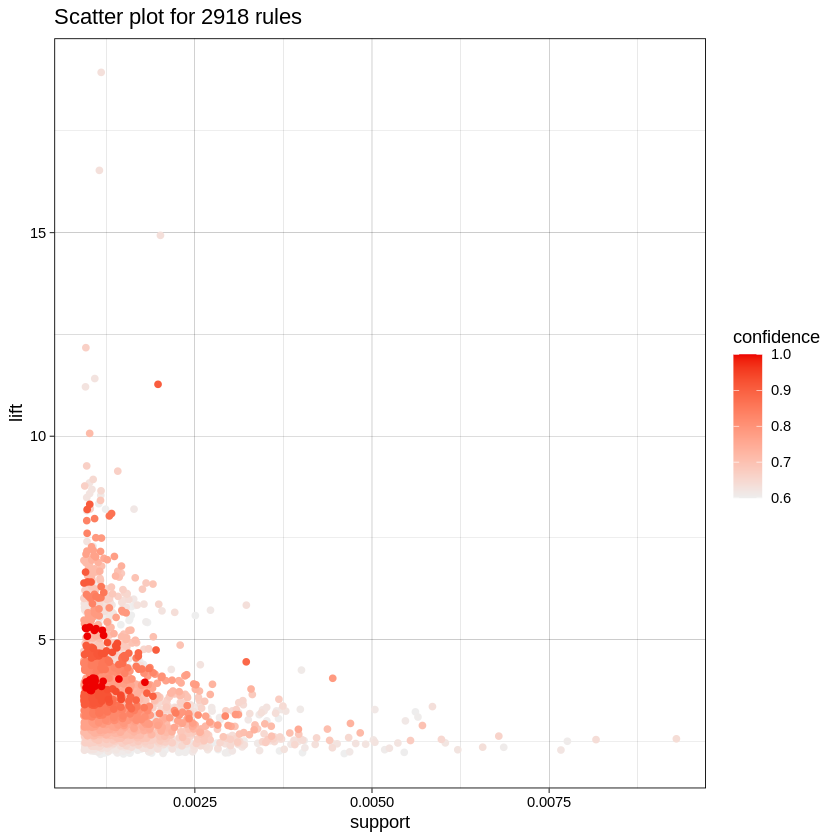

In [ ]:
plot(rulesg, measure=c("support","lift"), shading="confidence")

In [ ]:
subrulesg<-subset(rulesg,quality(rulesg)$lift>10)
inspect(head(sort(subrulesg,by="support"),20))

    lhs                         rhs                  support confidence    coverage     lift count
[1] {liquor,                                                                                      
     red/blush wine}         => {bottled beer}   0.001931876  0.9047619 0.002135231 11.23527    19
[2] {ham,                                                                                         
     processed cheese}       => {white bread}    0.001931876  0.6333333 0.003050330 15.04549    19
[3] {soda,                                                                                        
     popcorn}                => {salty snack}    0.001220132  0.6315789 0.001931876 16.69779    12
[4] {Instant food products,                                                                       
     soda}                   => {hamburger meat} 0.001220132  0.6315789 0.001931876 18.99565    12
[5] {hamburger meat,                                                                              
     yogur

Vamos a mirar productos centrales. Para facilitar, solo con confidence mayor a 0.7

Itemsets in Antecedent (LHS)
  [1] "{liquor,red/blush wine}"                                                   
  [2] "{curd,cereals}"                                                            
  [3] "{root vegetables,cereals}"                                                 
  [4] "{yogurt,cereals}"                                                          
  [5] "{butter,jam}"                                                              
  [6] "{whipped/sour cream,instant coffee}"                                       
  [7] "{soups,bottled beer}"                                                      
  [8] "{yogurt,Instant food products}"                                            
  [9] "{napkins,house keeping products}"                                          
 [10] "{whipped/sour cream,house keeping products}"                               
 [11] "{root vegetables,house keeping products}"                                  
 [12] "{pastry,sweet spreads}"                            

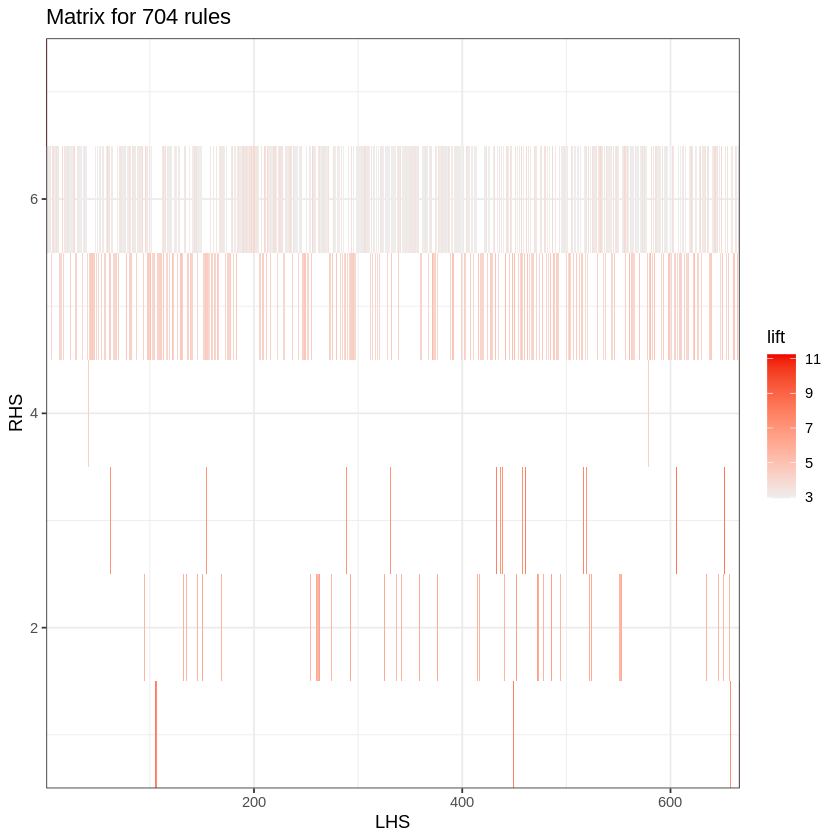

In [ ]:
subrulesg2<-subset(rulesg,quality(rulesg)$confidence>0.75)
plot (subrulesg2, method="matrix", measure=c("lift", "support"),
      control=list(reorder='support/confidence'))

Grafos

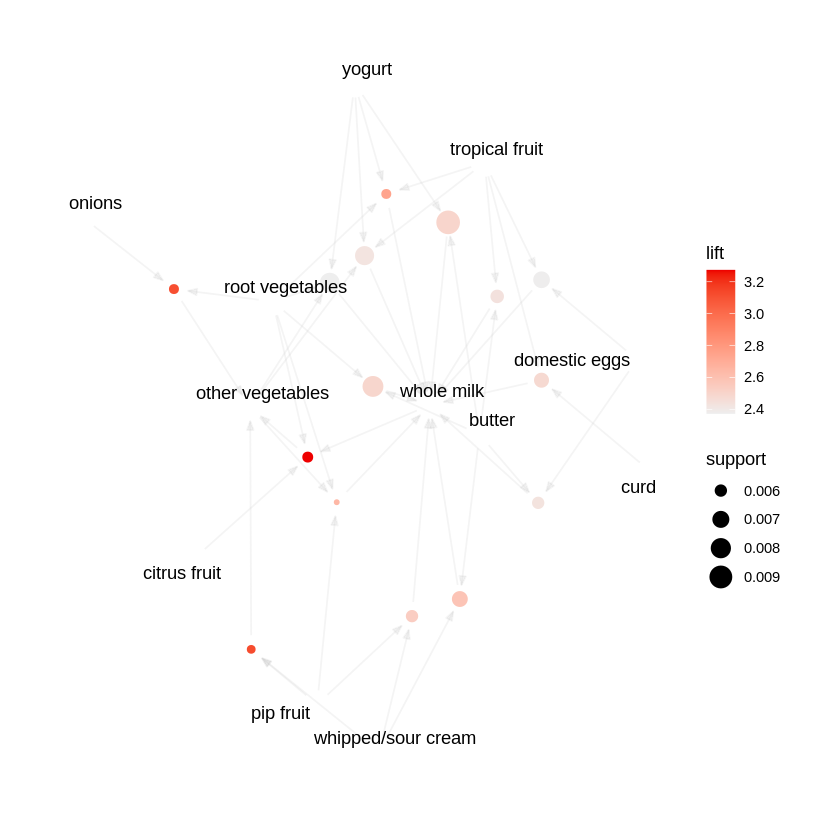

In [ ]:
subrulesg2a <- head(sort(rulesg, by="support"), 15)
plot(subrulesg2a, method="graph")

Warning message:
“Unknown control parameters: arrowSize”


Available control parameters (with default values):
layout	 =  stress
circular	 =  FALSE
ggraphdots	 =  NULL
edges	 =  <environment>
nodes	 =  <environment>
nodetext	 =  <environment>
colors	 =  c("#EE0000FF", "#EEEEEEFF")
engine	 =  ggplot2
max	 =  100
verbose	 =  FALSE


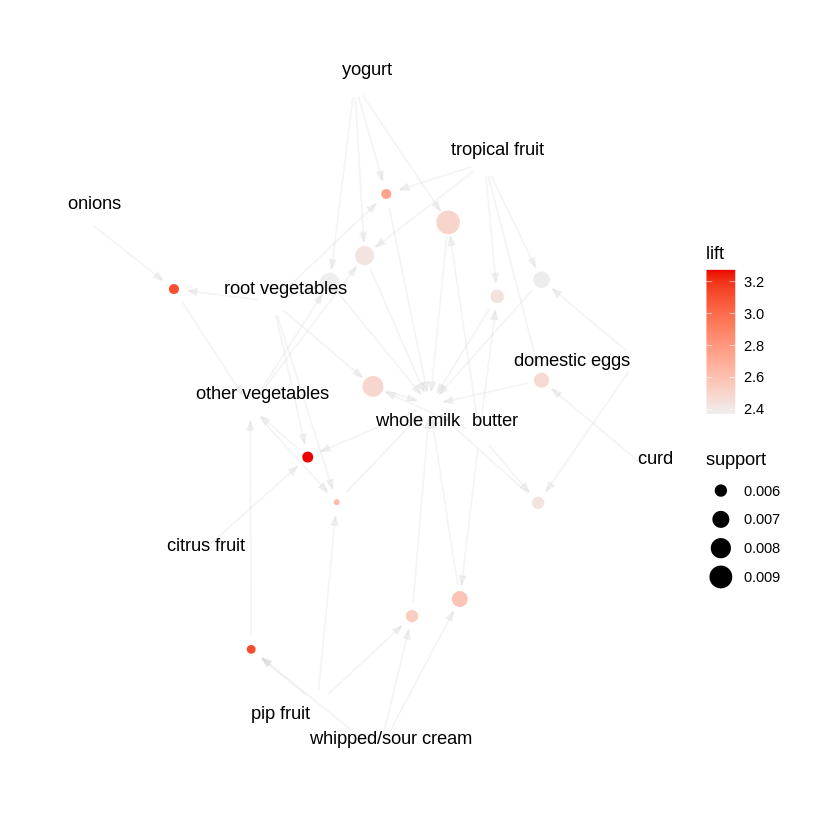

In [ ]:
plot(subrulesg2a, method="graph", arrowSize=.01)

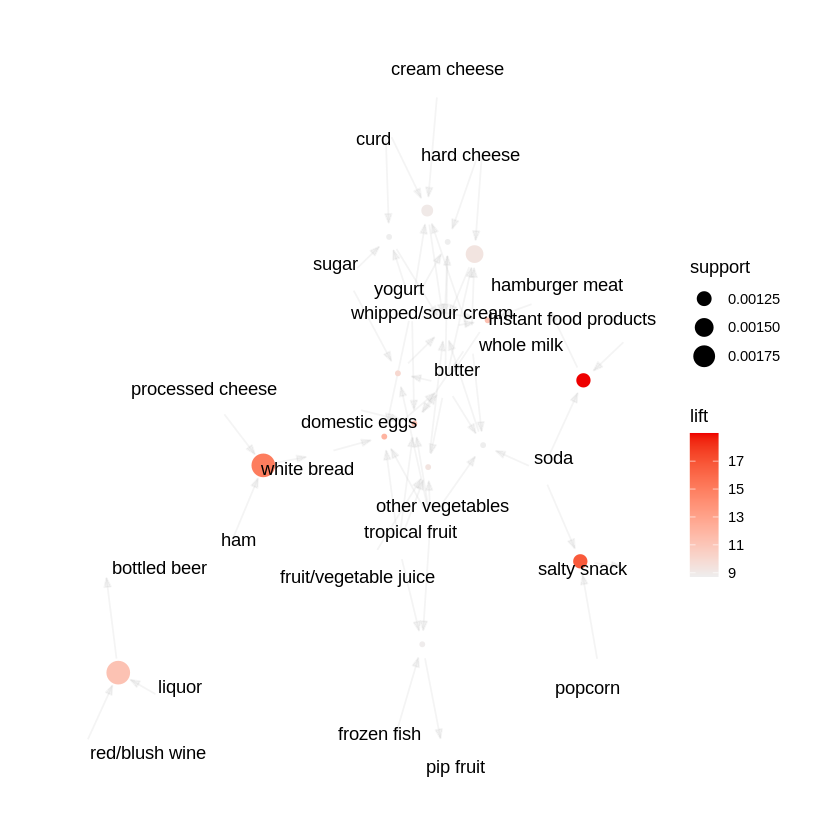

In [ ]:
subrulesg3 <- head(sort(rulesg, by="lift"), 15)
plot(subrulesg3, method="graph")

Warning message:
“Unknown control parameters: arrowSize”


Available control parameters (with default values):
layout	 =  stress
circular	 =  FALSE
ggraphdots	 =  NULL
edges	 =  <environment>
nodes	 =  <environment>
nodetext	 =  <environment>
colors	 =  c("#EE0000FF", "#EEEEEEFF")
engine	 =  ggplot2
max	 =  100
verbose	 =  FALSE


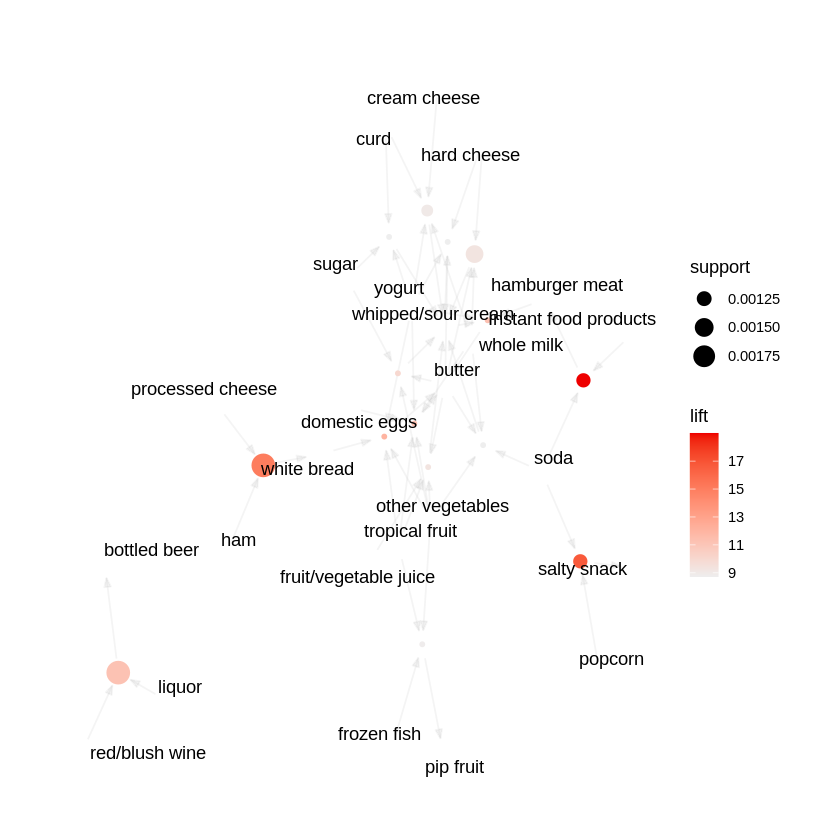

In [ ]:
plot(subrulesg3, method="graph", arrowSize=.01)

Producto Final

In [ ]:
Groceries@itemInfo$labels
rules_producto<-subset(rulesg,subset=lhs %in% "candles")
inspect(head(sort(rules_producto,by="lift"),20))

[1] "frankfurter"               "sausage"                  
  [3] "liver loaf"                "ham"                      
  [5] "meat"                      "finished products"        
  [7] "organic sausage"           "chicken"                  
  [9] "turkey"                    "pork"                     
 [11] "beef"                      "hamburger meat"           
 [13] "fish"                      "citrus fruit"             
 [15] "tropical fruit"            "pip fruit"                
 [17] "grapes"                    "berries"                  
 [19] "nuts/prunes"               "root vegetables"          
 [21] "onions"                    "herbs"                    
 [23] "other vegetables"          "packaged fruit/vegetables"
 [25] "whole milk"                "butter"                   
 [27] "curd"                      "dessert"                  
 [29] "butter milk"               "yogurt"                   
 [31] "whipped/sour cream"        "beverages"                
 [33] "UHT-milk"                  "condensed milk"           
 [35] "cream"                     "soft cheese"              
 [37] "sliced cheese"             "hard cheese"              
 [39] "cream cheese "             "processed cheese"         
 [41] "spread cheese"             "curd cheese"              
 [43] "specialty cheese"          "mayonnaise"               
 [45] "salad dressing"            "tidbits"                  
 [47] "frozen vegetables"         "frozen fruits"            
 [49] "frozen meals"              "frozen fish"              
 [51] "frozen chicken"            "ice cream"                
 [53] "frozen dessert"            "frozen potato products"   
 [55] "domestic eggs"             "rolls/buns"               
 [57] "white bread"               "brown bread"              
 [59] "pastry"                    "roll products "           
 [61] "semi-finished bread"       "zwieback"                 
 [63] "potato products"           "flour"                    
 [65] "salt"                      "rice"                     
 [67] "pasta"                     "vinegar"                  
 [69] "oil"                       "margarine"                
 [71] "specialty fat"             "sugar"                    
 [73] "artif. sweetener"          "honey"                    
 [75] "mustard"                   "ketchup"                  
 [77] "spices"                    "soups"                    
 [79] "ready soups"               "Instant food products"    
 [81] "sauces"                    "cereals"                  
 [83] "organic products"          "baking powder"            
 [85] "preservation products"     "pudding powder"           
 [87] "canned vegetables"         "canned fruit"             
 [89] "pickled vegetables"        "specialty vegetables"     
 [91] "jam"                       "sweet spreads"            
 [93] "meat spreads"              "canned fish"              
 [95] "dog food"                  "cat food"                 
 [97] "pet care"                  "baby food"                
 [99] "coffee"                    "instant coffee"           
[101] "tea"                       "cocoa drinks"             
[103] "bottled water"             "soda"                     
[105] "misc. beverages"           "fruit/vegetable juice"    
[107] "syrup"                     "bottled beer"             
[109] "canned beer"               "brandy"                   
[111] "whisky"                    "liquor"                   
[113] "rum"                       "liqueur"                  
[115] "liquor (appetizer)"        "white wine"               
[117] "red/blush wine"            "prosecco"                 
[119] "sparkling wine"            "salty snack"              
[121] "popcorn"                   "nut snack"                
[123] "snack products"            "long life bakery product" 
[125] "waffles"                   "cake bar"                 
[127] "chewing gum"               "chocolate"                
[129] "cooking chocolate"         

    lhs                          rhs          support     confidence
[1] {tropical fruit, candles} => {whole milk} 0.001016777 0.6666667 
    coverage    lift     count
[1] 0.001525165 2.609099 10   
